## Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_util import *

In [2]:
import time

In [77]:
no_epochs=20
val_split=0.15
sequence_length = 16  # sequence length

#### Tranining Data set

In [4]:
train_df = read_data(get_files(r'.*Case[1-6]_CutFre20.xls'),cut_precent=0.1) # case 1 -6 for traning
train_df.head()

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


,distance,acceleration,displacement,force
0,195.166667,-0.971085,0.058862,171.311496
1,195.250000,-1.077395,0.058892,171.652377
2,195.333333,-1.167291,0.058921,171.871397
3,195.416667,-1.239130,0.058949,171.960719
4,195.500000,-1.291503,0.058976,171.913955


In [6]:
# Selecting the relevant features
train_features = train_df[['acceleration', 'displacement']]
train_target = train_df['force']

X_train, y_train,idx_train = create_sequences(train_features, train_target, sequence_length)

#### Testing Data set

In [38]:
test_df = read_data(get_files(r'V300.*Case[7-8]_CutFre20.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test300, y_test300,idx300 = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Conv1D, Dense,LSTM,Bidirectional,Input,GRU,Flatten,Dropout,Attention
from tensorflow.keras import regularizers
from tensorflow import keras

In [13]:
rnn_model = Sequential([
    SimpleRNN(32, input_shape=(sequence_length, 2), return_sequences=True),
    SimpleRNN(32, return_sequences=False),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 16, 32)         │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,233 (12.63 KB)

 Trainable params: 3,233 (12.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
rnn_history = rnn_model.fit(X_train, y_train, epochs=no_epochs, validation_split=val_split, verbose=1)


Epoch 1/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 20945.6387 - val_loss: 1525.9357
Epoch 2/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 2031.8516 - val_loss: 551.1981
Epoch 3/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 595.6666 - val_loss: 433.7036
Epoch 4/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 343.8857 - val_loss: 384.3300
Epoch 5/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 329.5092 - val_loss: 428.5715
Epoch 6/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 322.8646 - val_loss: 379.0685
Epoch 7/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 315.9207 - val_loss: 355.5015
Epoch 8/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 309.3275 - val_loss: 390.4941
Epoch 9/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - loss: 303.8583 - val_loss: 374.5254
Epoch 10/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - loss: 304.9177 - val_loss: 375.8257
Epoch 11/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 2

In [27]:
rnn_model.save("models/rnn_model_fre_20_20.keras")
pd.DataFrame(data = rnn_history.history).to_csv("history/rnn_hist_fre2_20.csv")
# time.sleep(60*5)

In [15]:
gru_model = Sequential([
    GRU(32, input_shape=(sequence_length, 2), return_sequences=True),
    GRU(32, return_sequences=False),
    # SeqSelfAttention(attention_activation='sigmoid'),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 16, 32)         │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,825 (38.38 KB)

 Trainable params: 9,825 (38.38 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
gru_history = gru_model.fit(X_train, y_train, epochs=no_epochs, validation_split=val_split, verbose=1)

Epoch 1/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 55s 9ms/step - loss: 20123.0000 - val_loss: 1414.5525
Epoch 2/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 54s 9ms/step - loss: 1311.2015 - val_loss: 380.6436
Epoch 3/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 51s 8ms/step - loss: 336.8282 - val_loss: 343.7838
Epoch 4/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 56s 9ms/step - loss: 305.1032 - val_loss: 370.3711
Epoch 5/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 55s 9ms/step - loss: 298.8005 - val_loss: 349.9983
Epoch 6/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 54s 9ms/step - loss: 294.4294 - val_loss: 347.2967
Epoch 7/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 53s 9ms/step - loss: 290.4450 - val_loss: 339.1762
Epoch 8/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 49s 8ms/step - loss: 287.3573 - val_loss: 336.4647
Epoch 9/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 59s 10ms/step - loss: 286.8554 - val_loss: 337.3661
Epoch 10/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 60s 10ms/step - loss: 283.6552 - val_loss: 342.4448
Epoch 11/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 58s 10ms/step - loss

In [17]:
gru_model.save("models/gru_model_fre_20_20.keras")
pd.DataFrame(data = gru_history.history).to_csv("history/gru_hist_fre_20_20.csv")
time.sleep(60*5)

In [18]:
def cnn_gru_model(steps=sequence_length,feature_size=2, output_size=1,req=True):
    model = Sequential()
    model.add(Input(shape=(steps,feature_size)))
    model.add(Conv1D(64, 1, activation='relu'))
    model.add(GRU(32, return_sequences=True))
    model.add(GRU(32,return_sequences=False))
    model.add(Dense(output_size))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [19]:
cnn_gru_model = cnn_gru_model()
cnn_gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 16, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 16, 32)         │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,969 (62.38 KB)

 Trainable params: 15,969 (62.38 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
cnn_gru_history = cnn_gru_model.fit(X_train, y_train,  epochs=no_epochs, validation_split=val_split, verbose=1)

Epoch 1/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 61s 9ms/step - loss: 20441.7559 - val_loss: 1454.2068
Epoch 2/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 51s 8ms/step - loss: 1698.9502 - val_loss: 394.9726
Epoch 3/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 50s 8ms/step - loss: 368.9031 - val_loss: 351.5771
Epoch 4/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 54s 9ms/step - loss: 303.3370 - val_loss: 354.2116
Epoch 5/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 58s 10ms/step - loss: 294.7131 - val_loss: 336.5111
Epoch 6/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 58s 10ms/step - loss: 288.4005 - val_loss: 340.9637
Epoch 7/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - loss: 281.9667 - val_loss: 331.4431
Epoch 8/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 65s 11ms/step - loss: 273.0454 - val_loss: 286.3460
Epoch 9/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 57s 9ms/step - loss: 250.9507 - val_loss: 247.7565
Epoch 10/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 59s 10ms/step - loss: 206.2544 - val_loss: 202.0445
Epoch 11/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 60s 10ms/step - l

In [21]:
cnn_gru_model.save("models/cnn_gru_model_fre_20_20.keras")
pd.DataFrame(data = cnn_gru_history.history).to_csv("history/cnn_gru_hist_fre_20_20.csv")
# time.sleep(60*5)

In [22]:
# reg = regularizers.l1_l2(0.01)
def lstm_model(steps=sequence_length,feature_size=2, output_size=1,req=True):
    model = Sequential()
    # model.add(Input(shape=(steps,feature_size)))
    # model.add(Conv1D(64, 1, activation='relu'))
    model.add(LSTM(32,input_shape=(sequence_length, 2), return_sequences=True))
    model.add(LSTM(32,return_sequences=False))
    model.add(Dense(output_size))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [23]:
lstm_model = lstm_model()
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16, 32)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,833 (50.13 KB)

 Trainable params: 12,833 (50.13 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
lstm_history = lstm_model.fit(X_train, y_train,  epochs=no_epochs, validation_split=val_split, verbose=1)

Epoch 1/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 52s 8ms/step - loss: 20396.6387 - val_loss: 1439.5869
Epoch 2/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 48s 8ms/step - loss: 1338.0648 - val_loss: 374.2786
Epoch 3/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 339.3630 - val_loss: 351.6484
Epoch 4/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 48s 8ms/step - loss: 304.0509 - val_loss: 347.8037
Epoch 5/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 50s 8ms/step - loss: 296.8334 - val_loss: 358.5133
Epoch 6/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 48s 8ms/step - loss: 291.9895 - val_loss: 356.8512
Epoch 7/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 49s 8ms/step - loss: 289.9960 - val_loss: 367.8743
Epoch 8/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 48s 8ms/step - loss: 286.4998 - val_loss: 337.7308
Epoch 9/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 50s 8ms/step - loss: 282.1845 - val_loss: 358.8217
Epoch 10/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 48s 8ms/step - loss: 277.0313 - val_loss: 388.2162
Epoch 11/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 48s 8ms/step - loss: 2

In [25]:
lstm_model.save("models/lstm_model_fre_20_20.keras")
pd.DataFrame(data = lstm_history.history).to_csv("history/lstm_hist_re_20_20.csv")
time.sleep(60*5)

In [28]:
rnn_pred = rnn_model.predict(X_test300)
gru_pred = gru_model.predict(X_test300)
lstm_pred = lstm_model.predict(X_test300)
cnn_gru_pred = cnn_gru_model.predict(X_test300)
# dnn_pred1 = dnn_model1.predict(test_features[sequence_length:])

826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [ ]:
lstm_pred.shape

In [ ]:
gru_pred.shape

In [ ]:
plt.scatter(y_test,lstm_pred);
plt.xlabel("Force")
plt.ylabel("Predicted Force");

In [ ]:
plt.scatter(y_test,cnn_gru_pred);
plt.xlabel("Force")
plt.ylabel("Predicted Force");

In [104]:
def plot_slot(start=500,end=601,filename="image"):
    epoch_count = idx300[start:end]

    plt.plot(epoch_count, y_test300[start:end], 'ro-',linewidth=2.0,markevery=20)
    # plt.plot(epoch_count, dnn_pred1[start:end], 'm--',linewidth=2.0)
    # plt.plot(epoch_count, dnn_pred[start:end], 'b--',linewidth=2.0)
    plt.plot(epoch_count, gru_pred[start:end], 'm^--',linewidth=2.0,markevery=20)
    plt.plot(epoch_count, cnn_gru_pred[start:end], 'bX--',linewidth=2.0,markevery=20)
    plt.plot(epoch_count, rnn_pred[start:end], 'yh--',linewidth=2.0,markevery=20)
    plt.plot(epoch_count, lstm_pred[start:end], 'gd--',linewidth=2.0,markevery=20)
    plt.legend(['Force',"GRU","CNN-GRU", "RNN","LSTM"])
    plt.xlabel('Distance (m)')
    plt.ylabel('Force (N)')
    #plt.title(title)
    plt.grid(True)
    plt.savefig("images/"+filename+".pdf",dpi=200,format = "pdf")
    # plt.show()
    

In [105]:
SMALL_SIZE = 14
MEDIUM_SIZE = 14
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rcParams["figure.figsize"] = (8,6)
plt.style.use("classic")


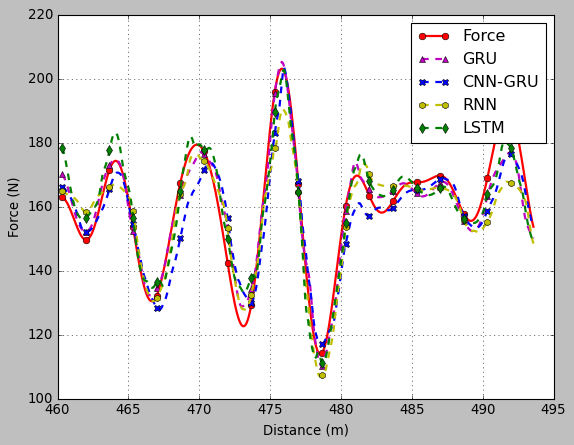

In [108]:
plot_slot(3400,3800,"ex2_train_Fre20_test_on_Fre20_Case7_8")

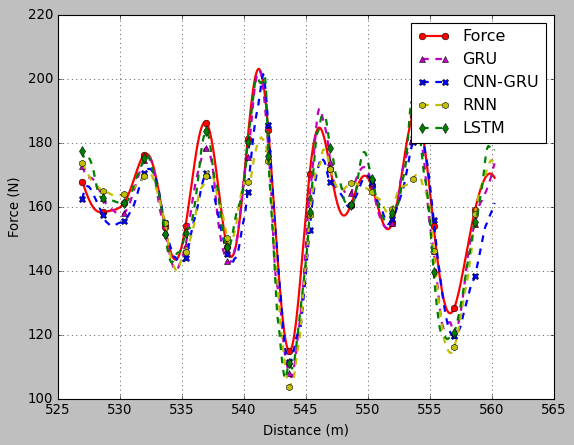

In [106]:
plot_slot(4200,4600,"ex1_train_Fre20_test_on_Fre20_Case7_8")

In [71]:
df_val = pd.DataFrame(data = {
              # "DNN-TM":dnn_history.history["val_loss"],
              "RNN":rnn_history.history["val_loss"],
              "GRU":gru_history.history["loss"],
              "CNN_GRU":cnn_gru_history.history["loss"],
              "LSTM":rnn_history.history["val_loss"]
                                         })
df_val.head()
df_val.to_csv("history/val_loss.csv")

In [72]:
df_val = pd.DataFrame(data = {
              # "DNN-TM":dnn_history.history["loss"],
              "RNN":rnn_history.history["loss"],
              "GRU":gru_history.history["loss"],
              "CNN_GRU":cnn_gru_history.history["loss"],
              "LSTM":rnn_history.history["loss"]
                                         })
df_val.head()
df_val.to_csv("history/loss.csv")

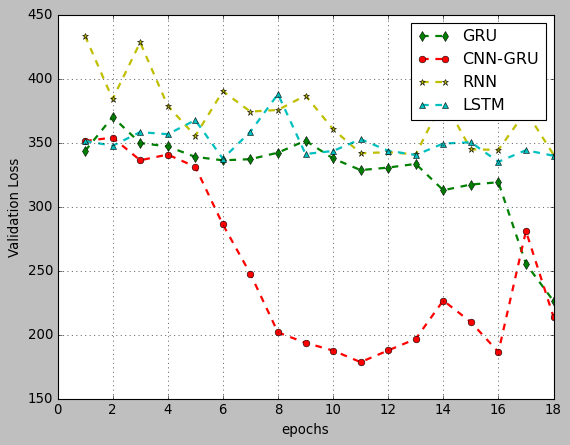

In [73]:
def plot_models_performance(gru=None, rnn=None, lstm=None,cnn_gru=None, title="Proctive Model"):
    lstm_accuracy = lstm.history['val_loss'][2:no_epochs]
    rnn_accuracy = rnn.history['val_loss'][2:no_epochs]
    gru_accuracy = gru.history['val_loss'][2:no_epochs]
    gru_att_acc = cnn_gru.history['val_loss'][2:no_epochs]


    # Create count of the number of epochs
    epoch_count = range(1, len(lstm_accuracy) + 1)

    # Visualize loss history
    plt.plot(epoch_count, gru_accuracy, 'gd--',linewidth=2.0)
    plt.plot(epoch_count, gru_att_acc, 'ro--',linewidth=2.0)
    plt.plot(epoch_count, rnn_accuracy, 'y*--',linewidth=2.0)
    plt.plot(epoch_count, lstm_accuracy, 'c^--',linewidth=2.0)
   
    plt.legend(['GRU','CNN-GRU', "RNN", "LSTM"])
    plt.xlabel('epochs')
    plt.ylabel('Validation Loss')
    plt.grid(True)
    plt.savefig("images/"+"val_loss.pdf",dpi=200,format = "pdf")

plot_models_performance(gru_history,rnn_history,lstm_history,cnn_gru_history,title="Adaptive Validation Loss")

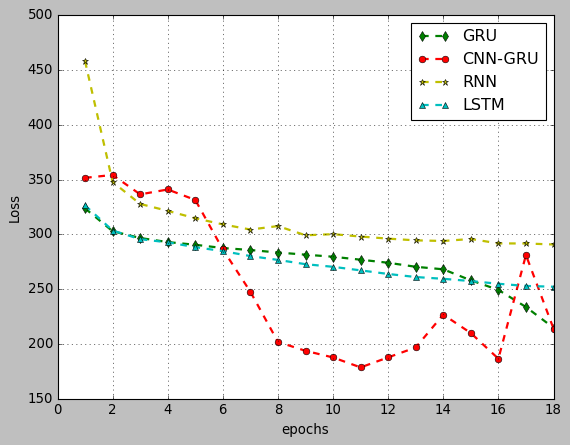

In [74]:
def plot_models_performance(gru=None, rnn=None, lstm=None, gru_att=None,title="Proctive Model"):
    lstm_accuracy = lstm.history['loss'][2:no_epochs]
    rnn_accuracy = rnn.history['loss'][2:no_epochs]
    gru_accuracy = gru.history['loss'][2:no_epochs]
    gru_att_acc = gru_att.history['val_loss'][2:no_epochs]


    # Create count of the number of epochs
    epoch_count = range(1, len(lstm_accuracy) + 1)

    # Visualize loss history
    plt.plot(epoch_count, gru_accuracy, 'gd--',linewidth=2.0)
    plt.plot(epoch_count, gru_att_acc, 'ro--',linewidth=2.0)
    plt.plot(epoch_count, rnn_accuracy, 'y*--',linewidth=2.0)
    plt.plot(epoch_count, lstm_accuracy, 'c^--',linewidth=2.0)
    # plt.plot(epoch_count, deep_nn_accuracy, 'b--')
    plt.legend(['GRU','CNN-GRU', "RNN", "LSTM"])
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    # plt.title(title)
    plt.grid(True)
    plt.savefig("images/"+"loss.pdf",dpi=200,format = "pdf")

plot_models_performance(gru_history,rnn_history,lstm_history,cnn_gru_history,title="Loss")

In [83]:
test_df = read_data(get_files(r'V300.*Case[7-8]_CutFre20.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test, y_test,idx = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


In [84]:
from sklearn.metrics import mean_squared_error
# from tensorflow.keras.metrics import MeanSquaredError 

In [87]:
def plot_error():
    rnn_pred = rnn_model.predict(X_test).reshape(-1)
    gru_pred = gru_model.predict(X_test).reshape(-1)
    lstm_pred = lstm_model.predict(X_test).reshape(-1)
    gru_att_pred = cnn_gru_model.predict(X_test).reshape(-1)
    # dnn_pred1 = dnn_model1.predict(test_features[sequence_length:])

    rnn_mse = mean_squared_error(y_test,rnn_pred)
    # dnn_tm_mse = mean_squared_error(dnn_pred, y_test)
    # dnn_mse = mean_squared_error(dnn_pred1, y_test)
    gru_mse = mean_squared_error(y_test,gru_pred)
    gru_att_mse = mean_squared_error(y_test,gru_att_pred)
    lstm_mse = mean_squared_error(y_test,lstm_pred)

    fig, ax = plt.subplots()
    fruits = ['RNN','GRU','CNN-GRU', 'LSTM']
    counts = [rnn_mse, gru_mse, gru_att_mse, lstm_mse]
    bar_labels = ['RNN','GRU','CNN-GRU', 'LSTM']
    bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange']

    ax.bar(fruits, counts, label=bar_labels, color=bar_colors)

    ax.set_ylabel('Mean Sqaure Error',fontsize=17) 
    # ax.set_title('Fruit supply by kind and color')
    # ax.legend(title='Models')
    plt.grid(True)

    plt.xticks(rotation=45,fontsize=17) 
    plt.yticks(fontsize=17) 
    # plt.show()
    # plt.savefig("images/"+finame+".pdf",dpi=200,format = "pdf")
    return counts

826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


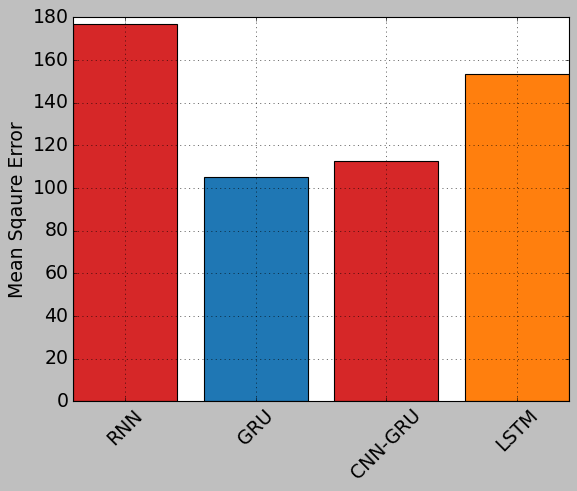

In [88]:
trained_Fre20_test_Fre20_V300 = plot_error()

In [90]:
test_df = read_data(get_files(r'V350.*Case[7-8]_CutFre20.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test, y_test,idx = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


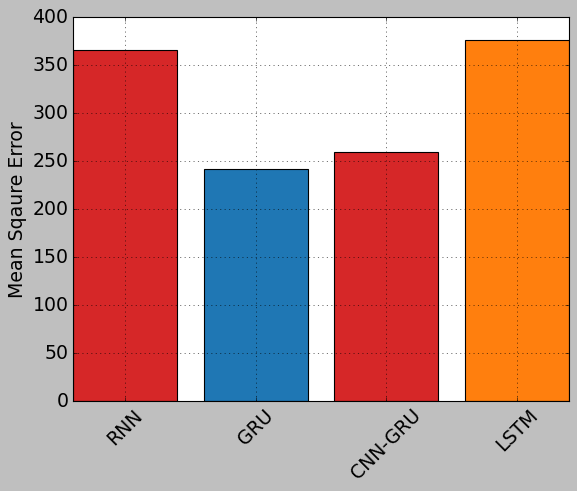

In [91]:
trained_Fre20_test_Fre20_V350 = plot_error()

2533/2533 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


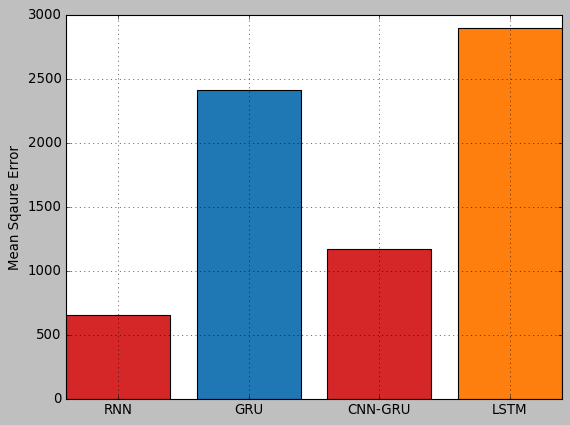

In [61]:
trained_Fre20_test_Fre20_V380

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


653/653 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


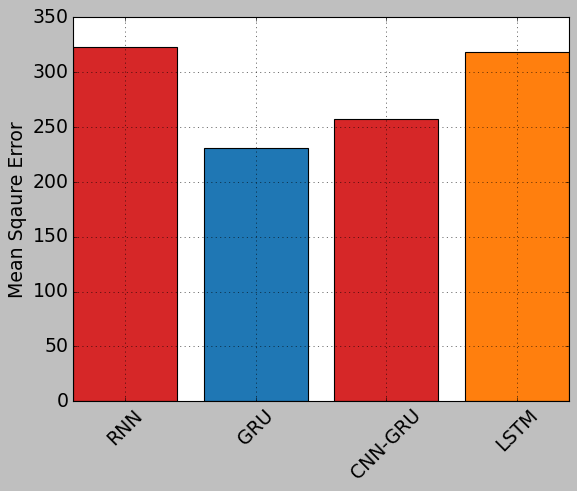

In [93]:
test_df = read_data(get_files(r'V380.*Case[7-8]_CutFre20.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test, y_test,idx = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)
trained_Fre20_test_Fre20_V380 = plot_error()

In [101]:
error_df = pd.DataFrame(data={
    "300":trained_Fre20_test_Fre20_V300,
    "350":trained_Fre20_test_Fre20_V350,
    "380":trained_Fre20_test_Fre20_V380,
                             })
error_df.index = ['RNN','CNN-GRU','GRU', 'LSTM']
error_df.head()

,300,350,380
RNN,176.823215,365.804132,323.180938
CNN-GRU,104.942202,241.935254,230.876091
GRU,112.867194,259.791237,256.903448
LSTM,153.345404,376.335915,318.801621


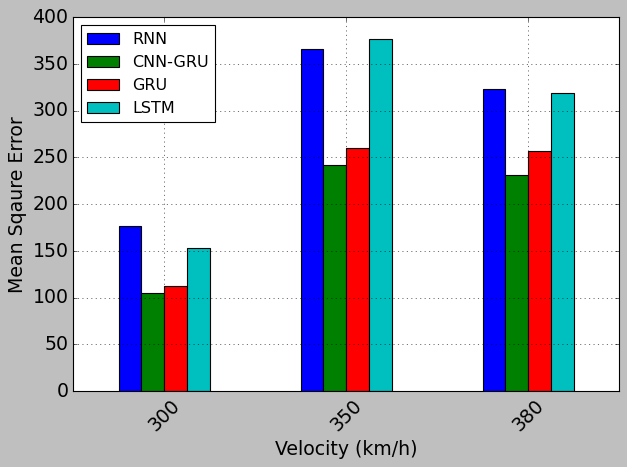

In [103]:
plt.rcParams.update({'figure.autolayout': True})
error_df.transpose().plot(kind="bar")
plt.xlabel("Velocity (km/h)",fontsize=17) 
plt.ylabel("Mean Sqaure Error",fontsize=17) 
plt.xticks(rotation=45,fontsize=17) 
plt.yticks(fontsize=17) 
plt.grid(True)
plt.savefig("images/mode_freq20.pdf",dpi=200,format = "pdf")